Importing setup files

In [1]:
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader

C:\Users\USER\AppData\Local\Temp\ipykernel_2796\3056932391.py:3: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import SentenceTransformer, InputExample, losses


Loading training triples

In [2]:
triples_df = pd.read_csv("phase7_training_triples.csv")

print("Training triples:", triples_df.shape)
triples_df.head()

Training triples: (8100, 6)


,query_id,anchor,positive,hard_negative,similarity_score,topic
0,0,How can blood donation centers collaborate wit...,Collaboration may involve implementing evidenc...,How can blood donation centers collaborate wit...,1.000000,Blood Type
1,0,How can blood donation centers collaborate wit...,Collaboration may involve implementing evidenc...,How can blood donation centers collaborate wit...,0.912461,Blood Type
2,0,How can blood donation centers collaborate wit...,Collaboration may involve implementing evidenc...,How can blood donation centers collaborate wit...,0.908266,Blood Type
3,1,What strategies can be employed to address the...,Strategies to address stigma and discriminatio...,What strategies can be employed to address the...,1.000000,Other
4,1,What strategies can be employed to address the...,Strategies to address stigma and discriminatio...,What measures can be implemented to address th...,0.935312,Other


Converting triples into training examples

In [3]:
train_examples = [
    InputExample(
        texts=[row.anchor, row.positive, row.hard_negative]
    )
    for row in triples_df.itertuples()
]

print("Training examples created:", len(train_examples))

Training examples created: 8100


Loading base MPNet model

In [4]:
model = SentenceTransformer("all-mpnet-base-v2")

print("Base MPNet loaded successfully.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Base MPNet loaded successfully.


Creating dataloader

In [5]:
train_dataloader = DataLoader(
    train_examples,
    shuffle=True,
    batch_size=8
)

Defining TripletLoss

In [6]:
train_loss = losses.TripletLoss(model=model)

Start fine-tuning

In [7]:
model.fit(    
    train_objectives=[(train_dataloader, train_loss)],
    epochs=1,
    warmup_steps=100,
    show_progress_bar=True
)

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
500,4.802645
1000,4.677207


Saving fine-tuned model

In [8]:
model.save("mpnet_donor_finetuned")

print("Fine-tuned MPNet saved successfully.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned MPNet saved successfully.


Reloading model for evaluation

In [9]:
from sentence_transformers import SentenceTransformer

finetuned_model = SentenceTransformer("mpnet_donor_finetuned")

print("Fine-tuned model loaded.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Fine-tuned model loaded.


## Validation Evaluation of Fine-Tuned MPNet

Load train and validation datasets

In [10]:
import pandas as pd
from sentence_transformers import SentenceTransformer, util
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv("train.csv")
validation_df = pd.read_csv("validation.csv")

print("Train shape:", train_df.shape)
print("Validation shape:", validation_df.shape)

Train shape: (2700, 2)
Validation shape: (338, 2)


Prepare training and validation question-answer lists

In [11]:
train_questions = train_df["Question"].tolist()
train_answers = train_df["Answer"].tolist()

validation_questions = validation_df["Question"].tolist()
validation_answers = validation_df["Answer"].tolist()

print("Training questions:", len(train_questions))
print("Validation questions:", len(validation_questions))

Training questions: 2700
Validation questions: 338


Load the fine-tuned model

In [12]:
finetuned_model = SentenceTransformer("mpnet_donor_finetuned")

print("Fine-tuned MPNet loaded successfully.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Fine-tuned MPNet loaded successfully.


Encode all training questions using the fine-tuned model

In [13]:
finetuned_train_embeddings = finetuned_model.encode(
    train_questions,
    convert_to_tensor=True,
    show_progress_bar=True
)

print("Fine-tuned training embeddings created.")
print("Embedding shape:", finetuned_train_embeddings.shape)

Batches:   0%|          | 0/85 [00:00<?, ?it/s]

Fine-tuned training embeddings created.
Embedding shape: torch.Size([2700, 768])


Define retrieval function for the fine-tuned model

In [14]:
def retrieve_answer_finetuned(user_query, questions, answers, embeddings, model):
    query_embedding = model.encode(user_query, convert_to_tensor=True)
    
    similarities = util.cos_sim(query_embedding, embeddings)[0]
    best_match_index = similarities.argmax().item()
    best_score = similarities[best_match_index].item()
    
    matched_question = questions[best_match_index]
    retrieved_answer = answers[best_match_index]
    
    return {
        "user_query": user_query,
        "matched_question": matched_question,
        "retrieved_answer": retrieved_answer,
        "similarity_score": best_score
    }

Run validation retrieval using the fine-tuned model

In [15]:
finetuned_results = []

for true_question, true_answer in zip(validation_questions, validation_answers):
    output = retrieve_answer_finetuned(
        true_question,
        train_questions,
        train_answers,
        finetuned_train_embeddings,
        finetuned_model
    )
    
    finetuned_results.append({
        "validation_question": true_question,
        "expected_answer": true_answer,
        "matched_question": output["matched_question"],
        "retrieved_answer": output["retrieved_answer"],
        "similarity_score": output["similarity_score"]
    })

finetuned_results_df = pd.DataFrame(finetuned_results)

print("Fine-tuned validation retrieval completed.")
finetuned_results_df.head()

Fine-tuned validation retrieval completed.


,validation_question,expected_answer,matched_question,retrieved_answer,similarity_score
0,What impact do intergenerational donation even...,"Intergenerational donation events, such as fam...",Question 51 How can community-based blood dona...,Hosting blood donation events in familiar and ...,0.982971
1,How do blood drive hosts collaborate with acad...,Blood drive hosts collaborate with academic in...,How do blood drive hosts engage with local gov...,Blood drive hosts engage with local government...,0.997817
2,What factors contribute to disparities in bloo...,Disparities in blood donation rates among diff...,What factors contribute to disparities in bloo...,Disparities in blood donation rates among raci...,0.919082
3,What role can celebrity endorsements and partn...,Celebrity endorsements and influencer partners...,What role can celebrity endorsements and influ...,Celebrity endorsements and influencer partners...,0.809935
4,How does blood donation support families of pa...,Blood donation supports families of patients b...,How can donating blood promote intergeneration...,Blood donation can encourage families to parti...,0.823986


Similarity score summary

In [16]:
print("Fine-tuned Validation Similarity Score Summary:")
print(finetuned_results_df["similarity_score"].describe())

Fine-tuned Validation Similarity Score Summary:
count    338.000000
mean       0.932125
std        0.124380
min        0.306821
25%        0.932165
50%        0.992031
75%        0.999146
max        0.999951
Name: similarity_score, dtype: float64


Compute fine-tuned semantic retrieval accuracy

In [17]:
finetuned_accuracy_085 = (finetuned_results_df["similarity_score"] >= 0.85).mean() * 100
finetuned_accuracy_090 = (finetuned_results_df["similarity_score"] >= 0.90).mean() * 100

print("Fine-tuned MPNet Semantic Retrieval Accuracy (>= 0.85):", round(finetuned_accuracy_085, 2), "%")
print("Fine-tuned MPNet Strict Semantic Retrieval Accuracy (>= 0.90):", round(finetuned_accuracy_090, 2), "%")

Fine-tuned MPNet Semantic Retrieval Accuracy (>= 0.85): 83.14 %
Fine-tuned MPNet Strict Semantic Retrieval Accuracy (>= 0.90): 77.81 %


Compare fine-tuned MPNet with baseline MPNet

In [18]:
comparison_finetuned_df = pd.DataFrame({
    "Metric": [
        "Semantic Accuracy >= 0.85",
        "Strict Semantic Accuracy >= 0.90"
    ],
    "Baseline MPNet": [
        83.73,
        62.72
    ],
    "Fine-Tuned MPNet": [
        round(finetuned_accuracy_085, 2),
        round(finetuned_accuracy_090, 2)
    ]
})

comparison_finetuned_df["Improvement"] = (
    comparison_finetuned_df["Fine-Tuned MPNet"] - comparison_finetuned_df["Baseline MPNet"]
)

comparison_finetuned_df

,Metric,Baseline MPNet,Fine-Tuned MPNet,Improvement
0,Semantic Accuracy >= 0.85,83.73,83.14,-0.59
1,Strict Semantic Accuracy >= 0.90,62.72,77.81,15.09


View best validation cases

In [19]:
best_finetuned_cases = finetuned_results_df.sort_values("similarity_score", ascending=False).head(10)

best_finetuned_cases[[
    "validation_question",
    "matched_question",
    "retrieved_answer",
    "similarity_score"
]]

,validation_question,matched_question,retrieved_answer,similarity_score
203,How do blood donation organizations collaborat...,How do blood donation organizations collaborat...,Blood donation organizations collaborate with ...,0.999951
224,What considerations should blood donation cent...,What considerations should blood donation cent...,Blood donation centers should consider factors...,0.999944
58,How can blood donation centers collaborate wit...,How can blood donation centers collaborate wit...,Collaboration with local media outlets can inv...,0.999943
163,What strategies can blood centers employ to pr...,What strategies can blood centers employ to pr...,Blood centers can employ strategies such as ta...,0.999942
45,How can blood donation centers effectively man...,How can blood donation centers effectively man...,Centers can manage expectations by providing a...,0.999941
157,How do blood donation centers ensure the safet...,How do blood donation centers ensure the safet...,Blood donation centers ensure the safety and q...,0.999928
111,How can blood donation centers leverage social...,How do blood donation centers leverage social ...,Blood donation centers collaborate with social...,0.999925
208,How can blood donation centers personalize app...,How can blood donation centers personalize app...,Blood donation centers can personalize appoint...,0.999923
89,How do blood donation centers ensure the ethic...,How do blood donation centers ensure the ethic...,Blood donation centers ensure the ethical recr...,0.999917
305,How can blood donation centers leverage data a...,How do blood donation centers leverage data an...,Blood donation centers analyze historical dona...,0.999893


View weakest validation cases

In [20]:
worst_finetuned_cases = finetuned_results_df.sort_values("similarity_score", ascending=True).head(20)

worst_finetuned_cases[[
    "validation_question",
    "matched_question",
    "retrieved_answer",
    "similarity_score"
]]

,validation_question,matched_question,retrieved_answer,similarity_score
131,How can individuals benefit from quitting smok...,What is the timing of withdrawal for individua...,The approved guidelines define the timing of w...,0.306821
86,How can donating blood inspire acts of kindness?,How do perceptions of donation as a means of e...,Perceptions of donation as a means of expressi...,0.387010
79,How can individuals benefit from consuming mor...,What is the current reliance status on emergen...,"There is no reliance; instead, the response is...",0.393578
18,How can donating blood create lasting positive...,How do past experiences with blood donation im...,"Past experiences with blood donation, whether ...",0.429852
44,How can perceptions of blood donation impact d...,How do public perceptions and media portrayals...,Public perceptions and media portrayals of blo...,0.437752
28,What role does community mobilization play in ...,How does the community-based blood donation pr...,The community-based blood donation program aim...,0.464856
12,What role do donor education and pre-donation ...,What role does donor education and counseling ...,Education and counseling can increase donor aw...,0.497248
81,How can appointment scheduling systems be opti...,How can appointment scheduling systems incorpo...,Appointment scheduling systems can incorporate...,0.511124
25,How can automated blood collection contribute ...,How can automated blood collection contribute ...,Automated blood collection contributes to a mo...,0.547537
219,What factors contribute to demographic dispari...,What factors contribute to disparities in bloo...,Disparities in blood donation rates among raci...,0.571478


Visualize similarity score distribution

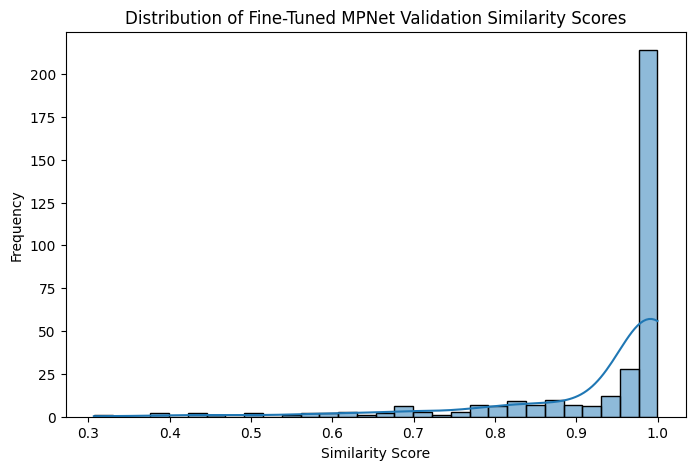

In [21]:
plt.figure(figsize=(8, 5))
sns.histplot(finetuned_results_df["similarity_score"], bins=30, kde=True)
plt.title("Distribution of Fine-Tuned MPNet Validation Similarity Scores")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.show()

Save Phase 9 outputs

In [22]:
finetuned_results_df.to_csv("phase9_validation_results_finetuned_mpnet.csv", index=False)
best_finetuned_cases.to_csv("phase9_best_validation_cases_finetuned_mpnet.csv", index=False)
worst_finetuned_cases.to_csv("phase9_worst_validation_cases_finetuned_mpnet.csv", index=False)
comparison_finetuned_df.to_csv("phase9_baseline_vs_finetuned_comparison.csv", index=False)

print("Saved Phase 9 validation outputs.")

Saved Phase 9 validation outputs.


Create Phase 9 summary table

In [23]:
phase9_summary = {
    "Validation samples": len(finetuned_results_df),
    "Fine-Tuned Semantic Accuracy (>= 0.85)": round(finetuned_accuracy_085, 2),
    "Fine-Tuned Strict Accuracy (>= 0.90)": round(finetuned_accuracy_090, 2),
    "Average similarity score": round(finetuned_results_df["similarity_score"].mean(), 4),
    "Minimum similarity score": round(finetuned_results_df["similarity_score"].min(), 4),
    "Maximum similarity score": round(finetuned_results_df["similarity_score"].max(), 4)
}

phase9_summary_df = pd.DataFrame(list(phase9_summary.items()), columns=["Metric", "Value"])
phase9_summary_df

,Metric,Value
0,Validation samples,338.0000
1,Fine-Tuned Semantic Accuracy (>= 0.85),83.1400
2,Fine-Tuned Strict Accuracy (>= 0.90),77.8100
3,Average similarity score,0.9321
4,Minimum similarity score,0.3068
5,Maximum similarity score,1.0000
